# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 4. Матричный профиль. Поиск примитивов на его основе.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы четвертой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [1]:
import os

practice_dir_path = 'D:/PycharmProjects/TimeSeriesCourse/practice/04 Matrix profile'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [2]:
%load_ext autoreload
%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 4.

In [ ]:
import os
import sys

current_dir = os.getcwd()

# Ставим текущую папку на первое место для поиска модулей
sys.path.insert(0, current_dir)

In [4]:
import os
import modules

print("Рабочая директория:", os.getcwd())
print("Путь к modules:", list(modules.__path__))
print("Содержимое modules:", os.listdir(list(modules.__path__)[0]))

Рабочая директория: D:\PycharmProjects\TimeSeriesCourse\practice\04 Matrix profile
Путь к modules: ['D:\\PycharmProjects\\TimeSeriesCourse\\practice\\04 Matrix profile\\modules']
Содержимое modules: ['discords.py', 'meter_swapping_detection.py', 'motifs.py', 'mp.py', 'plots.py', 'utils.py', '__init__.py', '__pycache__']


In [5]:
import pandas as pd
import numpy as np
import os
import datetime

from modules.plots import *
from modules.mp import compute_mp
from modules.motifs import top_k_motifs
from modules.discords import top_k_discords
from modules.meter_swapping_detection import *

## **Часть 1.** Матричный профиль. Поиск мотивов и диссонансов.

### **Задача 1.**
Загрузите временной ряд, который содержит данные о почасовом потреблении электроэнергии некоторого итальянского города, снимаемые в течение 3 лет, начиная с 1 января 1995 года.

In [6]:
ts_url = './datasets/part1/italianpowerdemand.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд, используя функцию `plot_ts()` из модуля *plot.py*.

In [7]:
plot_ts(ts, "Input time series")

<!doctype html>

Анализ временных рядов на основе матричного профиля осуществляет библиотека [stumpy](https://stumpy.readthedocs.io/en/latest/index.html). Напишите функцию `compute_mp()` в модуле *mp.py*, которая вычисляет матричный профиль временного ряда на основе выбранной вами функции из библиотеки *stumpy*.

In [8]:
m = 165
excl_zone = int(np.ceil(m / 2))
mp = {}

# Вызываем функцию compute_mp из модуля mp
mp = compute_mp(ts, m, exclusion_zone=excl_zone)

Визуализируйте найденный матричный профиль ряда.

In [9]:
plot_ts(mp['mp'], "Matrix Profile")

<!doctype html>

### **Задача 2.**
Выполните поиск top-$k$ мотивов в исходном временном ряде на основе построенного матричного профиля. Для этого реализуйте самостоятельно функцию `top_k_motifs()` в модуле *motifs.py*. Среди найденных мотивов не должно быть тривиальных совпадений, поэтому в `top_k_motifs()` добавьте вызов функции `apply_exclusion_zone()` из модуля *utils.py*.

In [10]:
top_k = 6
motifs = {}

motifs = top_k_motifs(mp, top_k)

Выполните визуализацию найденных top-$k$ мотивов с помощью функции `plot_motifs()` из *plots.py*.

In [11]:
plot_motifs(mp, motifs)

<!doctype html>

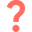
Проанализируйте и изложите содержательный смысл полученных результатов.

Мотив – это подпоследовательность временного ряда, имеющая хотя бы одного «двойника» – другую подпоследовательность той же длины, которая очень близка к ней по форме. В матричном профиле такие фрагменты отмечаются глубокими «ямами» (локальными минимумами), поскольку расстояние до ближайшего соседа у них минимально. Другими словами, мотив – это повторяющийся паттерн, «шаблон», который встречается в ряде более одного раза.

Функция top_k_motifs для каждого мотива возвращает не один индекс, а пару индексов: сам мотив и его ближайшего соседа (MPI). На верхнем графике каждая пара выделяется одним цветом – два фрагмента временного ряда, наложенных друг на друга. На нижних подграфиках показано попарное наложение этих фрагментов: чем плотнее две кривые совпадают, тем меньше расстояние между ними и тем «сильнее» мотив.


### **Задача 3.**
Реализуйте самостоятельно функцию `top_k_discords()` в модуле *discords.py*, предназначенную для поиска top-$k$ диссонансов во временном ряде на основе матричного профиля. Чтобы исключить попадание тривиальных совпадений в результирующее множество диссонансов воспользуйтесь функцией `apply_exclusion_zone()` из модуля *utils.py*.

Загрузите временной ряд *nyc_taxi.csv* из директории *./datasets/part1/*, содежащий данные о среднем числе пассажиров NY такси за осень 2014 года.

In [12]:
ts_url = './datasets/part1/nyc_taxi.csv'

ts = pd.read_csv(ts_url, index_col=0, header=0).squeeze().to_numpy()
plot_ts(ts, "Input time series")

<!doctype html>

In [13]:
m = 96
excl_zone = int(np.ceil(m / 2))
mp = {}

mp = compute_mp(ts.astype(float), m, exclusion_zone=excl_zone)

In [14]:
top_k = 15
discords = {}

# Вызываем функцию top_k_discords из модуля discords
discords = top_k_discords(mp, top_k)

Выполните визуализацию найденных top-$k$ диссонансов.

In [15]:
plot_discords(mp, discords)

<!doctype html>

In [16]:
ts[discords['indices']]

array([23773, 18686, 14294,  1049, 25243,  7084,  3077, 20253,  9158,
       39197,  6446,  3459, 19147, 16514, 16686], dtype=int64)

In [17]:
pd.read_csv(ts_url).loc[discords['indices']]

,timestamp,value
9985,2015-01-25 00:30:00,23773
10048,2015-01-26 08:00:00,18686
8784,2014-12-31 00:00:00,14294
10097,2015-01-27 08:30:00,1049
8837,2015-01-01 02:30:00,25243
5868,2014-10-31 06:00:00,7084
105,2014-07-03 04:30:00,3077
9651,2015-01-18 01:30:00,20253
8449,2014-12-24 00:30:00,9158
5954,2014-11-02 01:00:00,39197


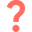
Проанализируйте и изложите содержательный смысл полученных результатов.


### Анализ обнаруженных диссонансов

Функция `plot_discords` позволяет визуализировать найденные аномалии на двух графиках:

1. **Верхний график** – исходный временной ряд NYC Taxi, на котором красным цветом выделены 15 наиболее выраженных диссонансов.
2. **Нижний график** – матричный профиль, где красными звёздочками отмечены максимумы, соответствующие обнаруженным диссонансам.

Чем выше значение матричного профиля, тем сильнее рассматриваемый фрагмент отличается от наиболее похожих на него участков временного ряда.

### Интерпретация результатов

Анализ полученных дат показывает, что многие обнаруженные диссонансы приходятся на праздничные дни, периоды изменения привычной активности населения и необычные погодные условия.

**Рассмотрим возможные причины появления аномалий:**

- **3–4 июля 2014 года** – празднование Дня независимости США. Изменение обычного распорядка жителей и увеличение числа праздничных мероприятий могли повлиять на количество поездок.
- **31 августа 2014 года** – выходные перед Днём труда. В этот период спрос на такси мог отличаться от стандартного недельного расписания.
- **31 октября 2014 года** – Хэллоуин. Праздничные мероприятия могли привести к изменению привычной активности пассажиров.
- **2 ноября 2014 года** – переход на зимнее время. Перевод часов назад мог повлиять на временные метки и структуру данных.
- **26 ноября 2014 года** – канун Дня благодарения. Из-за поездок перед праздником характер спроса на такси мог заметно измениться.
- **22, 24 и 28 декабря 2014 года** – рождественский период. Праздничные поездки и изменение рабочего графика жителей могли вызвать отклонения от обычной динамики.
- **31 декабря 2014 года и 1 января 2015 года** – новогодние праздники. Массовые мероприятия и ночные поездки могли привести к нетипичной нагрузке на службы такси.
- **25–27 января 2015 года** – период сильного снегопада в Нью-Йорке. Сложные погодные условия и ограничения движения могли существенно повлиять на количество поездок.

### Вывод

В результате анализа матричного профиля были выявлены **15 наиболее выраженных диссонансов** временного ряда NYC Taxi. Значительная часть обнаруженных аномалий совпадает с праздничными периодами или другими событиями, способными изменить привычный характер пассажирских поездок.

Таким образом, **матричный профиль позволяет находить участки временного ряда, существенно отличающиеся от остальных**. При этом для установления конкретных причин возникновения диссонансов необходимо дополнительно учитывать внешние факторы, например праздники, погодные условия и особенности сбора данных.


## **Часть 2.** Сегментация повторяющихся активностей.

### **Задача 4.**

Загрузите временной ряд PAMAP *pamap.csv* из директории *./datasets/part2/*, представляющий собой показания закрепленного на человеке виброакселерометра. Данный ряд включает показания, снятые при выполнении человеком трех видов физической активности: ходьба, подъем по лестнице и спуск по лестнице. Необходимо сегментировать временной ряд на основе его матричного профиля для определения того, когда человек шел и когда поднимался/спускался. Поскольку подъем и спуск по лестнице – это схожие действия, поэтому будем считать, что это одна активность.  

In [18]:
ts_url = './datasets/part2/pamap.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд PAMAP.

In [19]:
plot_ts(ts, "Input time series")

<!doctype html>

Найдите и визуализируйте матричный профиль временного ряда.

In [20]:
m = 100
excl_zone = m
mp = {}

mp = compute_mp(ts, m, exclusion_zone=excl_zone)

In [21]:
plot_ts(mp['mp'], "Matrix Profile")

<!doctype html>

Вычислите порог по формуле, которая представлена в презентации [04 Matrix profile.pdf](https://github.com/mzym/TimeSeriesCourse/blob/main/slides/04%20Matrix%20profile.pdf).

In [22]:
alpha = 0.5
# threshold = alpha * (mp['mp'].min() + mp['mp'].max())
threshold = alpha * (mp['mp'].min() + np.nanmax(mp['mp'][np.isfinite(mp['mp'].astype(float))]))
threshold

6.246194213752261

Выполните визуализацию результатов сегментации повторяющихся активностей.

In [23]:
plot_segmentation(mp, threshold)

<!doctype html>

Загрузите истинную разметку временного ряда PAMAP *pamap_labels.csv*, где 0 означает ходьбу, 1 – подъем по лестнице, 2 – спуск с лестницы. Вычислите точность по метрике accuracy, сравнив полученные результаты по основе матричного профиля с истинной разметкой.

In [24]:
labels_url = './datasets/part2/pamap_labels.csv'

labels = pd.read_csv(labels_url, header=None).squeeze().to_numpy()

In [25]:
# Предсказания на основе матричного профиля:
# 1 = ходьба (RA, где MP < threshold), 0 = лестница (вне RA)
preds = (mp['mp'].astype(float) < threshold).astype(int)

# Приводим истинные метки: 0 — ходьба, 1 и 2 — лестница (объединяем)
true_labels = (labels != 0).astype(int)

# Длины массивов могут различаться из-за длины подпоследовательностей.
# Сравниваем на общей длине.
n = min(len(preds), len(true_labels))
accuracy = np.mean(preds[:n] == true_labels[:n])

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9384


## **Чaсть 3.** Casy Study: Раскрытие краж электричества подменой счетчиков (meter-swapping detection).


### **Задача 5.**

Рассмотрим практическое применение использования матричного профиля для решения задачи, связанной с раскрытием краж электричества путем подмены счетчиков.

Загрузите временные ряды из директории *./datasets/part3/*, которые были выбраны случайным образом из набора данных (House 1, 2, 3, 4 и 11), содержащего данные потребления электроэнергии 20 жилых домов в Великобритании с 1 января по 23 декабря 2014 года.

In [25]:
path = './datasets/part3/'

house_idx = [1, 2, 3, 4, 11]

filenames = [f"House{i}.csv" for i in house_idx]

consumptions = {}
for house in filenames:
    consumptions[house[:-4]] = pd.read_csv(os.path.join(path, house), header=None, index_col=0)
    consumptions[house[:-4]].index = pd.to_datetime(consumptions[house[:-4]].index, format='%Y-%m-%d %H:%M:%S')#, dayfirst=True)

Далее смоделируем событие замены счетчика. Для этого каждый временной ряд разделим на две части: "Head" (до 1 октября) и "Tail" (после 1 октября). После чего выберем случайным образом 2 временных ряда (например, House1 и House11) и поменяем местами их "Tail" части.

In [27]:
cutoff = pd.to_datetime('2014-10-01')
heads, tails = heads_tails(consumptions, cutoff, house_idx)

#swap Heads and Tails of 1 and 11
swap1, swap2 = 1, 11
consumptions[f'House{swap1}'] = pd.concat([heads[f'H_{swap1}'], tails[f'T_{swap2}']])
consumptions[f'House{swap2}'] = pd.concat([heads[f'H_{swap2}'], tails[f'T_{swap1}']])
heads, tails = heads_tails(consumptions, cutoff, house_idx)

Визуализируйте исходные временные ряды и параллельную оси OY прямую, которая делит временные ряды на "Head" и "Tail" части.

Чтобы найти переставленную пару временных рядов, выполним следующее. Сначала составим временные ряды $H_i$ из всевозможных комбинаций "Head" и "Tail" частей исходных временных рядов $T_K$, где $1 \leq i \leq |T|^2$, $1 \leq K \leq |T|$. В нашем случае, $|T| = 5$.  Далее среди них найдем такую пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$. Минимальная оценка $swap\_score$ для пары рядов $(H_i, H_j)$ вычисляется следующим образом:

\begin{equation}
swap\_score(i,j) = \frac{\min{(Head_{H_i} \bowtie Tail_{H_j})}}{\min{(Head_{H_i} \bowtie Tail_{H_i})}+eps},
\end{equation}

где $\bowtie$ – операция нахождения матричного профиля между двумя временными рядами. Матричный профиль между двумя временными рядами содержит расстояния между всеми подпоследовательностями первого временного ряда и их ближайшими соседями, которые являются подпоследовательностями второго временного ряда.

Добавьте в функцию `compute_mp()` в модуле *mp.py* поддежку вычисления матричного профиля между двумя различными временными рядами и найдите пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$ среди всех пар.

In [29]:
m = 24 * 4

min_score = meter_swapping_detection(heads, tails, house_idx, m)

In [30]:
min_i, min_j, mp_j = min_score['i'], min_score['j'], min_score['mp_j']
print(f'Time series with minimum score is (H_{min_i}, T_{min_j}).')

Time series with minimum score is (H_11, T_1).


In [31]:
for i in house_idx:
    head_i = heads[f'H_{i}'].iloc[:, 0].to_numpy()
    for j in house_idx:
        if i == j:
            continue
        tail_j = tails[f'T_{j}'].iloc[:, 0].to_numpy()
        mp_ij = compute_mp(head_i, m, ts2=tail_j)
        print(f'i={i} j ={j}: min_ii={mp_ij["mp"].min():.4f}, median_ii={np.median(mp_ij["mp"]):.4f}')

i=1 j =2: min_ii=6.2651, median_ii=9.9304
i=1 j =3: min_ii=5.8442, median_ii=10.0806
i=1 j =4: min_ii=6.0797, median_ii=9.8314
i=1 j =11: min_ii=3.3917, median_ii=9.6941
i=2 j =1: min_ii=7.1489, median_ii=9.7903
i=2 j =3: min_ii=5.6817, median_ii=9.6242
i=2 j =4: min_ii=4.7180, median_ii=9.3933
i=2 j =11: min_ii=2.8019, median_ii=10.0376
i=3 j =1: min_ii=5.8876, median_ii=9.5475
i=3 j =2: min_ii=7.0186, median_ii=9.6853
i=3 j =4: min_ii=4.9530, median_ii=9.7398
i=3 j =11: min_ii=3.1507, median_ii=10.0461
i=4 j =1: min_ii=6.4421, median_ii=10.1770
i=4 j =2: min_ii=6.0542, median_ii=9.8769
i=4 j =3: min_ii=6.6105, median_ii=9.8929
i=4 j =11: min_ii=4.7137, median_ii=10.2660
i=11 j =1: min_ii=3.7970, median_ii=6.7270
i=11 j =2: min_ii=7.0794, median_ii=9.0782
i=11 j =3: min_ii=6.9937, median_ii=8.6148
i=11 j =4: min_ii=7.7891, median_ii=9.1567


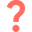
Проанализируйте и изложите содержательный смысл полученных результатов.